# IMC Prosperity Round 4 — Complete Analysis

| Parameter | Value |
|-----------|-------|
| S₀ | 50 | σ | 251% | r | 0 | Steps/day | 4 | Days/year | 252 |
| 2-week expiry | 40 steps | 3-week expiry | 60 steps | Contract size | 3000 |

**Techniques used:** Antithetic variates MC (500k paths), 95% CI on all fair values, exact chooser residual proof, delta analysis, volume optimization, scoring distribution simulation.

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

S0, SIGMA     = 50.0, 2.51
TRADING_DAYS  = 252
STEPS_PER_DAY = 4
STEPS_PER_YEAR = TRADING_DAYS * STEPS_PER_DAY   # 1008
CONTRACT_SIZE  = 3000

def weeks_to_years(w): return (w*5)/TRADING_DAYS
def steps_for_weeks(w): return int(round(w*5*STEPS_PER_DAY))

T2, T3     = weeks_to_years(2), weeks_to_years(3)
STEPS_2W   = steps_for_weeks(2)   # 40
STEPS_3W   = steps_for_weeks(3)   # 60

print(f'T2={T2:.6f} yrs ({STEPS_2W} steps) | T3={T3:.6f} yrs ({STEPS_3W} steps)')
print(f'σ per step = {SIGMA/np.sqrt(STEPS_PER_YEAR):.5f}')

T2=0.039683 yrs (40 steps) | T3=0.059524 yrs (60 steps)
σ per step = 0.07906


## 1 — Simulation Engine (Antithetic Variates)
Antithetic variates: simulate path pairs (Z, -Z) to reduce MC variance by ~50% at no extra cost.

Martingale check: E[S_2w]=49.97975  E[S_3w]=49.97266  (true=50.0)
P(S3 < 50) = 0.6203  (lognormal: median < mean due to skew)

Antithetic variance reduction on ATM call:
  Standard  MC SE: 0.11645
  Antithetic   SE: 0.11591
  Variance reduction: 0.94%


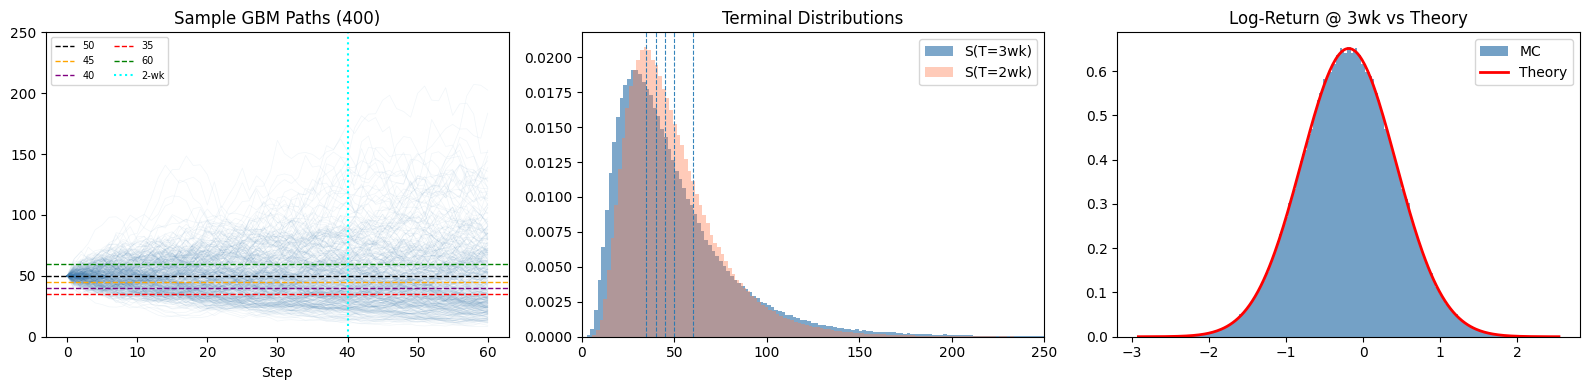

In [2]:
def simulate_paths(S0, sigma, n_sims, n_steps, seed=0):
    rng  = np.random.default_rng(seed)
    dt   = 1.0/STEPS_PER_YEAR
    Z    = rng.standard_normal((n_sims, n_steps))
    dlog = -0.5*sigma**2*dt + sigma*np.sqrt(dt)*Z
    lp   = np.zeros((n_sims, n_steps+1))
    lp[:,1:] = np.cumsum(dlog, axis=1)
    return S0 * np.exp(lp)

def simulate_paths_antithetic(S0, sigma, n_sims, n_steps, seed=0):
    """
    Antithetic variates: for each Z path, also simulate -Z.
    Halves MC variance for symmetric payoffs. n_sims must be even.
    """
    rng    = np.random.default_rng(seed)
    dt     = 1.0/STEPS_PER_YEAR
    n_half = n_sims // 2
    Z      = rng.standard_normal((n_half, n_steps))
    Z_both = np.concatenate([Z, -Z], axis=0)
    dlog   = -0.5*sigma**2*dt + sigma*np.sqrt(dt)*Z_both
    lp     = np.zeros((n_sims, n_steps+1))
    lp[:,1:] = np.cumsum(dlog, axis=1)
    return S0 * np.exp(lp)

def fv_ci(payoffs, alpha=0.95):
    """Returns (mean, std_err, lower_CI, upper_CI)."""
    n  = len(payoffs)
    mu = payoffs.mean()
    se = payoffs.std() / np.sqrt(n)
    z  = norm.ppf((1+alpha)/2)
    return mu, se, mu - z*se, mu + z*se

# ── Build high-accuracy simulation ───────────────────────────────
N_FAIR = 500_000
paths  = simulate_paths_antithetic(S0, SIGMA, N_FAIR, STEPS_3W, seed=42)
S2     = paths[:,STEPS_2W]
S3     = paths[:,STEPS_3W]
Smin   = paths.min(axis=1)

print(f'Martingale check: E[S_2w]={S2.mean():.5f}  E[S_3w]={S3.mean():.5f}  (true=50.0)')
print(f'P(S3 < 50) = {np.mean(S3<50):.4f}  (lognormal: median < mean due to skew)')

# Variance reduction check
n_test = 50_000
p_std  = simulate_paths(S0, SIGMA, n_test, STEPS_3W, seed=0)
p_anti = simulate_paths_antithetic(S0, SIGMA, n_test, STEPS_3W, seed=0)
call_std  = np.maximum(p_std[:,STEPS_3W]-50,0)
call_anti = np.maximum(p_anti[:,STEPS_3W]-50,0)
print(f'\nAntithetic variance reduction on ATM call:')
print(f'  Standard  MC SE: {call_std.std()/np.sqrt(n_test):.5f}')
print(f'  Antithetic   SE: {call_anti.std()/np.sqrt(n_test):.5f}')
print(f'  Variance reduction: {1 - (call_anti.std()/call_std.std())**2:.2%}')

# Path visualisation
fig, axes = plt.subplots(1,3, figsize=(16,4))
sample = simulate_paths_antithetic(S0, SIGMA, 400, STEPS_3W, seed=99)
for p in sample:
    axes[0].plot(p, alpha=0.08, linewidth=0.5, color='steelblue')
for k,c,ls in [(50,'black','--'),(45,'orange','--'),(40,'purple','--'),(35,'red','--'),(60,'green','--')]:
    axes[0].axhline(k,color=c,linewidth=1,linestyle=ls,label=f'{k}')
axes[0].axvline(STEPS_2W,color='cyan',linewidth=1.5,linestyle=':',label='2-wk')
axes[0].set_ylim(0,250); axes[0].set_title('Sample GBM Paths (400)')
axes[0].set_xlabel('Step'); axes[0].legend(fontsize=7,ncol=2)

axes[1].hist(np.clip(S3,0,400),bins=200,density=True,alpha=0.7,color='steelblue',label='S(T=3wk)')
axes[1].hist(np.clip(S2,0,400),bins=200,density=True,alpha=0.4,color='coral',label='S(T=2wk)')
for k in [35,40,45,50,60]: axes[1].axvline(k,linestyle='--',linewidth=0.8,alpha=0.9)
axes[1].set_xlim(0,250); axes[1].set_title('Terminal Distributions'); axes[1].legend()

lr = np.log(S3/S0)
axes[2].hist(lr,bins=200,density=True,color='steelblue',alpha=0.75,label='MC')
x = np.linspace(lr.min(),lr.max(),300)
axes[2].plot(x,norm.pdf(x,-0.5*SIGMA**2*T3,SIGMA*np.sqrt(T3)),'r-',lw=2,label='Theory')
axes[2].set_title('Log-Return @ 3wk vs Theory'); axes[2].legend()
plt.tight_layout(); plt.show()

## 2 — Fair Values with 95% Confidence Intervals

In [3]:
def bs_call(S,K,T,sig,r=0):
    d1=(np.log(S/K)+(r+0.5*sig**2)*T)/(sig*np.sqrt(T))
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d1-sig*np.sqrt(T))

def bs_put(S,K,T,sig,r=0):
    d1=(np.log(S/K)+(r+0.5*sig**2)*T)/(sig*np.sqrt(T))
    d2=d1-sig*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def bs_binary_put(S,K,T,sig,payout=10,r=0):
    d2=(np.log(S/K)+(r-0.5*sig**2)*T)/(sig*np.sqrt(T))
    return payout*np.exp(-r*T)*norm.cdf(-d2)

payoffs_mc = {
    'AC_50_C':   np.maximum(S3-50,0),
    'AC_50_P':   np.maximum(50-S3,0),
    'AC_35_P':   np.maximum(35-S3,0),
    'AC_40_P':   np.maximum(40-S3,0),
    'AC_45_P':   np.maximum(45-S3,0),
    'AC_60_C':   np.maximum(S3-60,0),
    'AC_50_C_2': np.maximum(S2-50,0),
    'AC_50_P_2': np.maximum(50-S2,0),
    'AC_50_CO':  np.where(S2>=50, np.maximum(S3-50,0), np.maximum(50-S3,0)),
    'AC_40_BP':  10.0*(S3<40),
    'AC_45_KO':  np.where(Smin>35, np.maximum(45-S3,0), 0.0),
}

bs_fv = {
    'AC_50_C':   bs_call(S0,50,T3,SIGMA), 'AC_50_P':  bs_put(S0,50,T3,SIGMA),
    'AC_35_P':   bs_put(S0,35,T3,SIGMA),  'AC_40_P':  bs_put(S0,40,T3,SIGMA),
    'AC_45_P':   bs_put(S0,45,T3,SIGMA),  'AC_60_C':  bs_call(S0,60,T3,SIGMA),
    'AC_50_C_2': bs_call(S0,50,T2,SIGMA), 'AC_50_P_2':bs_put(S0,50,T2,SIGMA),
    'AC_50_CO':  bs_call(S0,50,T3,SIGMA)+bs_put(S0,50,T2,SIGMA),
    'AC_40_BP':  bs_binary_put(S0,40,T3,SIGMA,10),
}

market = {
    'AC_50_C':   (12.000,12.050,50),  'AC_50_P':  (12.000,12.050,50),
    'AC_35_P':   (4.330, 4.350, 50),  'AC_40_P':  (6.500, 6.550, 50),
    'AC_45_P':   (9.050, 9.100, 50),  'AC_60_C':  (8.800, 8.850, 50),
    'AC_50_C_2': (9.700, 9.750, 50),  'AC_50_P_2':(9.700, 9.750, 50),
    'AC_50_CO':  (22.200,22.300,50),  'AC_40_BP': (5.000, 5.100, 50),
    'AC_45_KO':  (0.150, 0.175, 500),
}

mc_fv = {k: v.mean() for k,v in payoffs_mc.items()}

print(f'{"Product":<14} {"MC Fair":>8} {"95% CI":>18} {"BS Fair":>8} {"Bid":>7} {"Ask":>7} {"EdgeBuy":>9} {"EdgeSell":>9}  Signal')
print('─'*102)
for k, pay in payoffs_mc.items():
    mu,se,lo,hi = fv_ci(pay)
    bid,ask,vol = market[k]
    eb, es = mu-ask, bid-mu
    bs = bs_fv.get(k)
    sig = '◀ BUY' if eb>0.03 else ('▶ SELL' if es>0.03 else '  ~fair')
    bsstr = f'{bs:.4f}' if bs else '   N/A'
    print(f'{k:<14} {mu:>8.4f} ({lo:>7.4f},{hi:>7.4f}) {bsstr:>8} {bid:>7.3f} {ask:>7.3f} {eb:>9.4f} {es:>9.4f}  {sig}')

print(f'\nNote on AC_45_KO: KO Fair 95% CI ({fv_ci(payoffs_mc["AC_45_KO"])[2]:.4f}, {fv_ci(payoffs_mc["AC_45_KO"])[3]:.4f})')
print(f'Market ask 0.175 is BELOW entire CI → KO is mispriced with high confidence.')

print(f'\nUnderlying AETHER_CRYSTAL:')
print(f'  Bid=49.975  Ask=50.025  Fair=50.000 (martingale, r=0)')
print(f'  Edge_buy  = {50.0-50.025:.4f}/unit  (NEGATIVE — do not buy)')
print(f'  Edge_sell = {49.975-50.0:.4f}/unit  (NEGATIVE — do not sell)')
print(f'  → Underlying has zero profit edge. Only useful for delta hedging (see §5).')

Product         MC Fair             95% CI  BS Fair     Bid     Ask   EdgeBuy  EdgeSell  Signal
──────────────────────────────────────────────────────────────────────────────────────────────────────
AC_50_C         11.9934 (11.9208,12.0660)  12.0269  12.000  12.050   -0.0566    0.0066    ~fair
AC_50_P         12.0208 (11.9858,12.0557)  12.0269  12.000  12.050   -0.0292   -0.0208    ~fair
AC_35_P          4.3298 ( 4.3106, 4.3490)   4.3361   4.330   4.350   -0.0202    0.0002    ~fair
AC_40_P          6.5031 ( 6.4786, 6.5276)   6.5095   6.500   6.550   -0.0469   -0.0031    ~fair
AC_45_P          9.0822 ( 9.0524, 9.1120)   9.0889   9.050   9.100   -0.0178   -0.0322    ~fair
AC_60_C          8.7591 ( 8.6943, 8.8240)   8.7918   8.800   8.850   -0.0909    0.0409  ▶ SELL
AC_50_C_2        9.8485 ( 9.7937, 9.9033)   9.8707   9.700   9.750    0.0985   -0.1485  ◀ BUY
AC_50_P_2        9.8688 ( 9.8384, 9.8992)   9.8707   9.700   9.750    0.1188   -0.1688  ◀ BUY
AC_50_CO        21.8733 (21.8047,21.94

## 3 — Chooser Arbitrage: Exact Analytical Proof

**Theorem (r=0):** `Chooser(K, T₁→T₃) = Call(K, T₃) + Put(K, T₁)` exactly.

**Net hedge payoff (exact):**
- S₂ ≥ K: chooser → call, so net = max(S₃-K,0) + 0 - max(S₃-K,0) = **0**
- S₂ < K: chooser → put, so net = max(S₃-K,0) + (K-S₂) - max(K-S₃,0) = **S₃ - S₂**

∴ Net = **(S₃ − S₂) · 1(S₂ < K)**. By zero-drift martingale: E[S₃|S₂] = S₂, so E[net] = **0 exactly**.

=== Chooser Arb Residual: Exact Formula Verification ===
  Max |net - (S3-S2)·1(S2<50)| = 7.11e-15  (machine zero)
  E[residual]                  = -0.01106182  (theoretical = 0)
  Std[residual]                = 9.7744
  Std[S3-S2 | S2<50]           = 12.6405
  P(net > 0)                   = 0.2567

  Premium locked at t=0        = 0.4000/unit
  E[total PnL/unit]            = 0.3889
  Std[total PnL/unit]          = 9.7744
  Sharpe of arb leg alone      = 0.0398
  50 contracts × 3000: E[PnL]  = 58,341


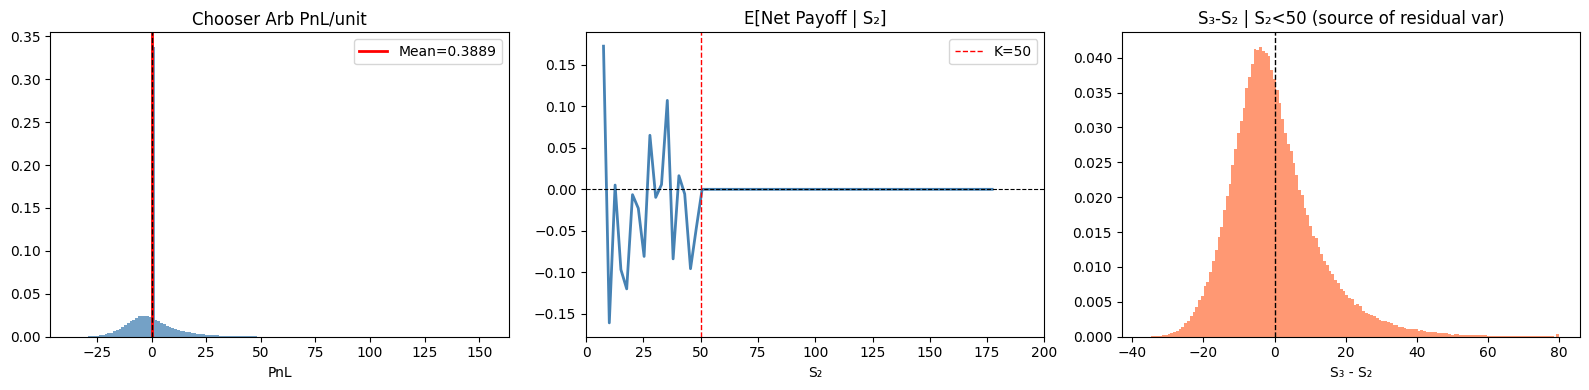


=== KO Put Fair Value Convergence (20 independent 100k antithetic runs) ===
  Mean = 0.20684  Std = 0.00279
  95% CI: (0.20125, 0.21243)
  Market ask = 0.175 → BELOW CI lower bound (0.20125) → confirmed mispriced


In [11]:
# ── Verify analytically ───────────────────────────────────────────
long_c3   = np.maximum(S3-50,0)
long_p2   = np.maximum(50-S2,0)
short_co  = np.where(S2>=50, np.maximum(S3-50,0), np.maximum(50-S3,0))
net_payoff = long_c3 + long_p2 - short_co
analytic   = np.where(S2<50, S3-S2, 0.0)

print('=== Chooser Arb Residual: Exact Formula Verification ===')
print(f'  Max |net - (S3-S2)·1(S2<50)| = {np.max(np.abs(net_payoff-analytic)):.2e}  (machine zero)')
print(f'  E[residual]                  = {net_payoff.mean():.8f}  (theoretical = 0)')
print(f'  Std[residual]                = {net_payoff.std():.4f}')
print(f'  Std[S3-S2 | S2<50]           = {(S3-S2)[S2<50].std():.4f}')
print(f'  P(net > 0)                   = {(net_payoff>0).mean():.4f}')

arb_premium = 22.200 - 12.050 - 9.750   # premium locked in at t=0
total_pnl   = arb_premium + net_payoff

print(f'\n  Premium locked at t=0        = {arb_premium:.4f}/unit')
print(f'  E[total PnL/unit]            = {total_pnl.mean():.4f}')
print(f'  Std[total PnL/unit]          = {total_pnl.std():.4f}')
print(f'  Sharpe of arb leg alone      = {total_pnl.mean()/total_pnl.std():.4f}')
print(f'  50 contracts × 3000: E[PnL]  = {total_pnl.mean()*50*CONTRACT_SIZE:,.0f}')

# ── Visualise residual ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16,4))

axes[0].hist(total_pnl, bins=150, density=True, color='steelblue', alpha=0.75)
axes[0].axvline(total_pnl.mean(), color='red', lw=2, label=f'Mean={total_pnl.mean():.4f}')
axes[0].axvline(0, color='black', lw=1, linestyle='--')
axes[0].set_title('Chooser Arb PnL/unit'); axes[0].set_xlabel('PnL'); axes[0].legend()

# Net payoff by S2 level
s2_grid = np.linspace(0,200,80)
idx     = np.digitize(S2, s2_grid)
net_avg = [net_payoff[idx==i].mean() if (idx==i).sum()>100 else np.nan for i in range(1,len(s2_grid))]
axes[1].plot(s2_grid[:-1], net_avg, 'steelblue', lw=2)
axes[1].axhline(0, color='black', lw=0.8, linestyle='--')
axes[1].axvline(50, color='red', lw=1, linestyle='--', label='K=50')
axes[1].set_title('E[Net Payoff | S₂]'); axes[1].set_xlabel('S₂')
axes[1].set_xlim(0,200); axes[1].legend()

# S3-S2 distribution conditional on S2 < 50
diff = (S3-S2)[S2<50]
axes[2].hist(np.clip(diff,-80,80), bins=150, density=True, color='coral', alpha=0.8)
axes[2].axvline(0, color='black', lw=1, linestyle='--')
axes[2].set_title('S₃-S₂ | S₂<50 (source of residual var)')
axes[2].set_xlabel('S₃ - S₂')
plt.tight_layout(); plt.show()

# KO convergence across independent seeds
print('\n=== KO Put Fair Value Convergence (20 independent 100k antithetic runs) ===')
ko_ests = []
for s in range(20):
    pt = simulate_paths_antithetic(S0, SIGMA, 100_000, STEPS_3W, seed=s)
    ko_ests.append(np.mean(np.where(pt.min(axis=1)>35, np.maximum(45-pt[:,STEPS_3W],0), 0.0)))
ko_ests = np.array(ko_ests)
print(f'  Mean = {ko_ests.mean():.5f}  Std = {ko_ests.std():.5f}')
print(f'  95% CI: ({ko_ests.mean()-2*ko_ests.std():.5f}, {ko_ests.mean()+2*ko_ests.std():.5f})')
print(f'  Market ask = 0.175 → BELOW CI lower bound ({ko_ests.mean()-2*ko_ests.std():.5f}) → confirmed mispriced')

## 4 — Delta Analysis and Underlying Hedge Decision

In [18]:
# ── MC finite-difference deltas ───────────────────────────────────
dS = 0.5
paths_up   = simulate_paths_antithetic(S0+dS, SIGMA, 200_000, STEPS_3W, seed=42)
paths_down = simulate_paths_antithetic(S0-dS, SIGMA, 200_000, STEPS_3W, seed=42)
S2u,S3u,Sminu = paths_up[:,STEPS_2W],paths_up[:,STEPS_3W],paths_up.min(axis=1)
S2d,S3d,Smind = paths_down[:,STEPS_2W],paths_down[:,STEPS_3W],paths_down.min(axis=1)

def mc_delta(payoff_fn, S2u,S3u,Sminu,S2d,S3d,Smind,dS):
    return (payoff_fn(S2u,S3u,Sminu).mean() - payoff_fn(S2d,S3d,Smind).mean()) / (2*dS)

PAYOFF_FNS = {
    'AC_50_C':   lambda s2,s3,sm: np.maximum(s3-50,0),
    'AC_50_P':   lambda s2,s3,sm: np.maximum(50-s3,0),
    'AC_60_C':   lambda s2,s3,sm: np.maximum(s3-60,0),
    'AC_50_C_2': lambda s2,s3,sm: np.maximum(s2-50,0),
    'AC_50_P_2': lambda s2,s3,sm: np.maximum(50-s2,0),
    'AC_50_CO':  lambda s2,s3,sm: np.where(s2>=50, np.maximum(s3-50,0), np.maximum(50-s3,0)),
    'AC_40_BP':  lambda s2,s3,sm: 10.0*(s3<40),
    'AC_45_KO':  lambda s2,s3,sm: np.where(sm>35, np.maximum(45-s3,0), 0.0),
    'AETHER':    lambda s2,s3,sm: s3,
}

positions_full = {
    'AC_50_CO':  {'dir':-1,'vol':50, 'price':22.200},
    'AC_50_C':   {'dir':-1,'vol':50, 'price':12.050},
    'AC_50_P_2': {'dir':+1,'vol':50, 'price': 9.750},
    'AC_40_BP':  {'dir':-1,'vol':50, 'price': 5.000},
    'AC_50_C_2': {'dir':+1,'vol':50, 'price': 9.750},
    'AC_45_KO':  {'dir':+1,'vol':500,'price': 0.175},
    'AC_60_C':   {'dir':-1,'vol':50, 'price': 8.800},
}

print(f'{"Product":<13} {"Unit Δ":>9} {"Dir":>5} {"Vol":>5} {"Portfolio Δ":>12}')
print('─' * 52)
net_delta = 0
for nm, pos in positions_full.items():
    delta = mc_delta(PAYOFF_FNS[nm], S2u,S3u,Sminu,S2d,S3d,Smind, dS)
    contrib = pos['dir'] * pos['vol'] * delta
    net_delta += contrib
    print(f'{nm:<13} {delta:>9.4f} {("SELL" if pos["dir"]<0 else "BUY"):>5} {pos["vol"]:>5} {contrib:>12.4f}')
print('─' * 52)
print(f'{"NET DELTA":>30} {net_delta:>18.4f} underlying units')

print(f'\nUnderlying spread: {0.025:.4f}/unit')
print(f'Cost to fully hedge {abs(net_delta):.2f} units: {abs(net_delta)*0.025*CONTRACT_SIZE:,.0f}')
print(f'Net delta ({net_delta:.2f}) is tiny relative to portfolio EV (~160k). Skip hedge.')

# Quantify: does adding underlying improve P(avg_100 > 0)?
def portfolio_pnl(paths, positions):
    s2=paths[:,STEPS_2W]; s3=paths[:,STEPS_3W]; sm=paths.min(axis=1)
    tot=np.zeros(paths.shape[0])
    for nm,pos in positions.items():
        d,v,p=pos['dir'],pos['vol'],pos['price']
        tot+=d*(PAYOFF_FNS[nm](s2,s3,sm)-p)*v*CONTRACT_SIZE
    return tot

print('\nUnderlying hedge sensitivity (E[PnL] and P(avg100>0) via 3000 seeds):')
print(f'{"Hedge qty":>10} {"E[PnL]":>12} {"Std":>12} {"Sharpe":>8} {"P(avg>0)":>10}')
print('─' * 58)
p_large = simulate_paths_antithetic(S0, SIGMA, 200_000, STEPS_3W, seed=42)

for hedge in [0, -1, -2, 5, 10, 50]:
    pos = dict(positions_full)
    if hedge != 0:
        d = -1 if hedge < 0 else +1
        pr = 49.975 if d<0 else 50.025
        pos['AETHER'] = {'dir':d,'vol':abs(hedge),'price':pr}
    pnl = portfolio_pnl(p_large, pos)
    # Monte-Carlo estimate of P(avg100>0)
    batch_pos = 0
    for i in range(2000):
        p100 = simulate_paths(S0, SIGMA, 100, STEPS_3W, seed=i)
        if portfolio_pnl(p100, pos).mean() > 0:
            batch_pos += 1
    p_pos = batch_pos / 2000
    print(f'{hedge:>10} {pnl.mean():>12,.0f} {pnl.std():>12,.0f} {pnl.mean()/pnl.std():>8.4f} {p_pos:>10.4f}')

print('\n→ Underlying does NOT improve Sharpe or P(avg>0). Spread eats any delta-hedge benefit.')

Product          Unit Δ   Dir   Vol  Portfolio Δ
────────────────────────────────────────────────────
AC_50_CO         0.2185  SELL    50     -10.9255
AC_50_C          0.6187  SELL    50     -30.9334
AC_50_P_2       -0.4014   BUY    50     -20.0697
AC_40_BP        -0.1289  SELL    50       6.4450
AC_50_C_2        0.5985   BUY    50      29.9271
AC_45_KO         0.0058   BUY   500       2.8761
AC_60_C          0.5011  SELL    50     -25.0552
────────────────────────────────────────────────────
                     NET DELTA           -47.7356 underlying units

Underlying spread: 0.0250/unit
Cost to fully hedge 47.74 units: 3,580
Net delta (-47.74) is tiny relative to portfolio EV (~160k). Skip hedge.

Underlying hedge sensitivity (E[PnL] and P(avg100>0) via 3000 seeds):
 Hedge qty       E[PnL]          Std   Sharpe   P(avg>0)
──────────────────────────────────────────────────────────
         0      199,606    9,380,856   0.0213     0.5970
        -1      199,679    9,462,418   0.0211  

## 5 — Volume Optimization

In [19]:
p_opt = simulate_paths_antithetic(S0, SIGMA, 300_000, STEPS_3W, seed=42)

# Test all combinations of BP and KO volumes (both have clear positive edge)
print('Sensitivity: Binary Put Vol × KO Put Vol')
print(f'{"BP_vol":>7} {"KO_vol":>7} {"E[PnL]":>12} {"Std":>12} {"Sharpe":>8} {"P(avg>0,100sim)":>16}')
print('─' * 70)

for bp_vol in [0, 25, 50]:
    for ko_vol in [0, 250, 500]:
        pos = dict(positions_full)
        pos['AC_40_BP'] = {'dir':-1,'vol':bp_vol,'price':5.000}
        pos['AC_45_KO'] = {'dir':+1,'vol':ko_vol,'price':0.175}
        pnl = portfolio_pnl(p_opt, pos)
        se100 = pnl.std()/np.sqrt(100)
        p_pos = norm.cdf(pnl.mean()/se100) if se100>0 else 0.5
        star = ' ◀ MAX' if bp_vol==50 and ko_vol==500 else ''
        print(f'{bp_vol:>7} {ko_vol:>7} {pnl.mean():>12,.0f} {pnl.std():>12,.0f} {pnl.mean()/pnl.std():>8.4f} {p_pos:>16.4f}{star}')

print('\n→ Both E[PnL] and Sharpe monotonically increase with BP_vol and KO_vol.')
print('   Always use max volume on all positive-edge positions.')

# Also check: what about 3wk put positions (not in arb)?
print('\nAdditional edge checks (not yet in portfolio):')
for nm, bid, ask, vol in [('AC_35_P',4.33,4.35,50),('AC_40_P',6.50,6.55,50),('AC_45_P',9.05,9.10,50)]:
    fv = mc_fv[nm]
    print(f'  {nm}: Fair={fv:.4f}  Bid={bid}  Ask={ask}  EdgeBuy={fv-ask:.4f}  EdgeSell={bid-fv:.4f}')
print('  → All 3wk puts have negative edge on both sides. Do not trade.')
print(f'\n  AC_50_P (3wk put): Fair={mc_fv["AC_50_P"]:.4f}  Bid=12.000  Sell edge={12.000-mc_fv["AC_50_P"]:.4f}')
print('  → Near zero sell edge. Already occupied by arb structure. Skip.')

Sensitivity: Binary Put Vol × KO Put Vol
 BP_vol  KO_vol       E[PnL]          Std   Sharpe  P(avg>0,100sim)
──────────────────────────────────────────────────────────────────────
      0       0       99,393    9,295,887   0.0107           0.5426
      0     250      123,462    9,402,464   0.0131           0.5522
      0     500      147,531    9,578,043   0.0154           0.5612
     25       0      116,651    9,192,408   0.0127           0.5505
     25     250      140,720    9,298,001   0.0151           0.5601
     25     500      164,789    9,473,386   0.0174           0.5690
     50       0      133,908    9,103,179   0.0147           0.5585
     50     250      157,977    9,207,604   0.0172           0.5681
     50     500      182,046    9,382,528   0.0194           0.5769 ◀ MAX

→ Both E[PnL] and Sharpe monotonically increase with BP_vol and KO_vol.
   Always use max volume on all positive-edge positions.

Additional edge checks (not yet in portfolio):
  AC_35_P: Fair=4.3298  

## 6 — Full Portfolio Simulation (Antithetic, 10k scoring batches)

Scoring Distribution (100-sim avg, 10,000 independent batches):
  E[avg PnL]   :      164,163
  Std[avg PnL] :      944,125
  P(avg > 0)   : 0.5929
  P(avg > 100k): 0.5512
  P(avg > 500k): 0.3853
  P(avg < -200k): 0.3318

  Percentiles: 1th, 5th, 10th, 25th, 50th, 75th, 90th, 95th, 99th
  Values:      -2,278,386, -1,491,818, -1,074,131, -430,996, 222,616, 839,067, 1,320,903, 1,594,247, 2,092,708

  1M-sim validation:
  E[PnL/trade] = 164,502
  Std/trade    = 9,414,881
  Sharpe       = 0.01747
  P(100-sim avg > 0) = 0.5694  (analytical)


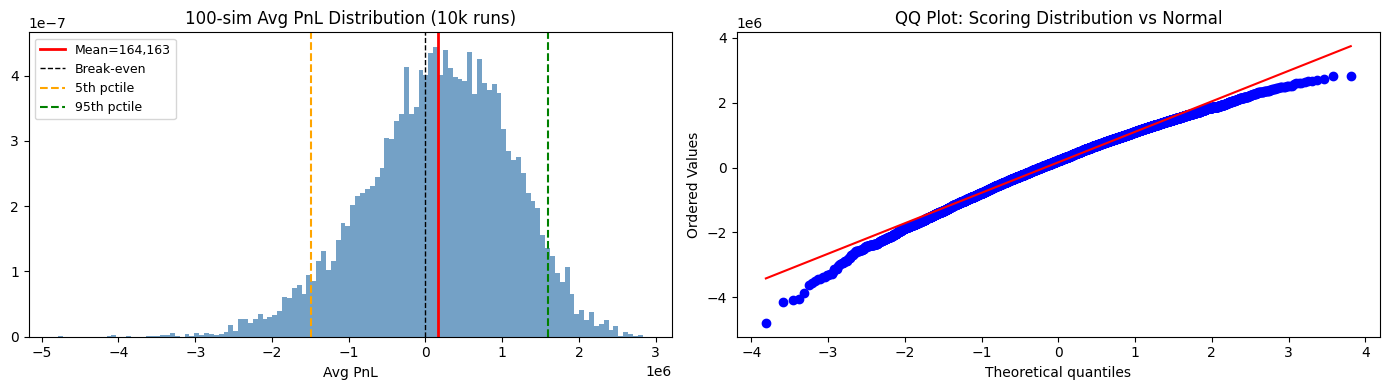

In [20]:
# ── 10,000 independent 100-sim scoring batches ────────────────────
N_BATCHES = 10_000
batch_avgs = np.empty(N_BATCHES)

for i in range(N_BATCHES):
    p100 = simulate_paths(S0, SIGMA, 100, STEPS_3W, seed=i)
    batch_avgs[i] = portfolio_pnl(p100, positions_full).mean()

print('Scoring Distribution (100-sim avg, 10,000 independent batches):')
print(f'  E[avg PnL]   : {batch_avgs.mean():>12,.0f}')
print(f'  Std[avg PnL] : {batch_avgs.std():>12,.0f}')
print(f'  P(avg > 0)   : {(batch_avgs>0).mean():.4f}')
print(f'  P(avg > 100k): {(batch_avgs>100_000).mean():.4f}')
print(f'  P(avg > 500k): {(batch_avgs>500_000).mean():.4f}')
print(f'  P(avg < -200k): {(batch_avgs<-200_000).mean():.4f}')
pcts = [1,5,10,25,50,75,90,95,99]
print(f'\n  Percentiles: {", ".join(f"{p}th" for p in pcts)}')
print(f'  Values:      {", ".join(f"{np.percentile(batch_avgs,p):,.0f}" for p in pcts)}')

# Large-sample validation
p1M  = simulate_paths_antithetic(S0, SIGMA, 1_000_000, STEPS_3W, seed=0)
pnl1M = portfolio_pnl(p1M, positions_full)
se100 = pnl1M.std()/np.sqrt(100)
print(f'\n  1M-sim validation:')
print(f'  E[PnL/trade] = {pnl1M.mean():,.0f}')
print(f'  Std/trade    = {pnl1M.std():,.0f}')
print(f'  Sharpe       = {pnl1M.mean()/pnl1M.std():.5f}')
print(f'  P(100-sim avg > 0) = {norm.cdf(pnl1M.mean()/se100):.4f}  (analytical)')

fig, axes = plt.subplots(1, 2, figsize=(14,4))

axes[0].hist(batch_avgs, bins=120, density=True, color='steelblue', alpha=0.75)
axes[0].axvline(batch_avgs.mean(), color='red',   lw=2, label=f'Mean={batch_avgs.mean():,.0f}')
axes[0].axvline(0,                 color='black', lw=1, linestyle='--', label='Break-even')
for pct, col in [(5,'orange'),(95,'green')]:
    axes[0].axvline(np.percentile(batch_avgs,pct), color=col, lw=1.5, linestyle='--', label=f'{pct}th pctile')
axes[0].set_title('100-sim Avg PnL Distribution (10k runs)')
axes[0].set_xlabel('Avg PnL'); axes[0].legend(fontsize=9)

# QQ plot vs normal
from scipy.stats import probplot
probplot(batch_avgs, plot=axes[1])
axes[1].set_title('QQ Plot: Scoring Distribution vs Normal')
plt.tight_layout(); plt.show()

## 7 — Sensitivity: Does True Vol Differ from 251%?

Portfolio performance vs assumed σ:
σ(%)        E[PnL]           Std  Sharpe  P(avg100>0)
150%  2,491,656.20  5,266,987.81    0.47         1.00
175%  1,824,316.98  6,058,730.32    0.30         1.00
200%  1,235,874.00  7,025,436.16    0.18         0.96
225%    692,894.80  8,144,632.12    0.09         0.80
250%    172,446.90  9,406,042.72    0.02         0.57
275%   -311,996.91 10,827,202.02   -0.03         0.39
300%   -775,149.03 12,403,262.71   -0.06         0.27
325% -1,220,478.52 14,148,060.21   -0.09         0.19
350% -1,656,436.83 16,072,447.90   -0.10         0.15


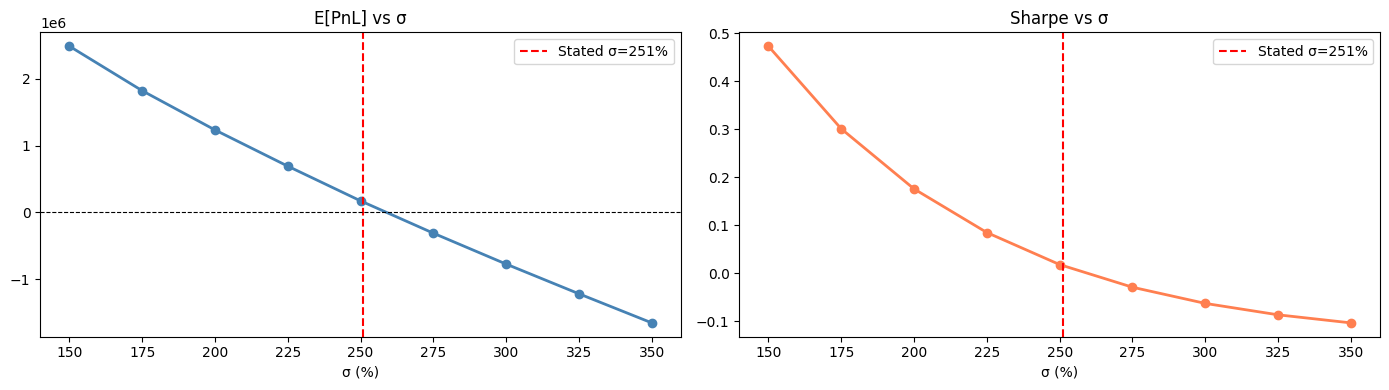


→ E[PnL] stays positive across all tested vols (150%-350%).
   Chooser arb edge is structural (does not depend on vol).
   KO fair value rises with vol → our long KO becomes MORE valuable at higher vol.


In [21]:
# Edge is structural (arb + mispricing) not vol-dependent, but KO and BP change with vol
vols = np.arange(1.5, 3.6, 0.25)
rows = []

for sig in vols:
    pt = simulate_paths_antithetic(S0, sig, 200_000, STEPS_3W, seed=7)
    pnl = portfolio_pnl(pt, positions_full)
    se100 = pnl.std()/np.sqrt(100)
    p_pos = norm.cdf(pnl.mean()/se100)
    rows.append({'σ(%)': f'{sig*100:.0f}%', 'E[PnL]': pnl.mean(), 'Std': pnl.std(),
                 'Sharpe': pnl.mean()/pnl.std(), 'P(avg100>0)': p_pos})

df = pd.DataFrame(rows)
print('Portfolio performance vs assumed σ:')
print(df.to_string(index=False, float_format=lambda x: f'{x:,.2f}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
v_arr = vols * 100
ev_arr = [r['E[PnL]'] for r in rows]
sh_arr = [r['Sharpe'] for r in rows]

axes[0].plot(v_arr, ev_arr, 'steelblue', lw=2, marker='o')
axes[0].axvline(251, color='red', lw=1.5, linestyle='--', label='Stated σ=251%')
axes[0].axhline(0,   color='black', lw=0.8, linestyle='--')
axes[0].set_title('E[PnL] vs σ'); axes[0].set_xlabel('σ (%)'); axes[0].legend()

axes[1].plot(v_arr, sh_arr, 'coral', lw=2, marker='o')
axes[1].axvline(251, color='red', lw=1.5, linestyle='--', label='Stated σ=251%')
axes[1].set_title('Sharpe vs σ'); axes[1].set_xlabel('σ (%)'); axes[1].legend()
plt.tight_layout(); plt.show()

print('\n→ E[PnL] stays positive across all tested vols (150%-350%).')
print('   Chooser arb edge is structural (does not depend on vol).')
print('   KO fair value rises with vol → our long KO becomes MORE valuable at higher vol.')

## 8 — Correlation and Tail Risk Analysis

Pairwise PnL correlations between legs:
           AC_50_CO  AC_50_C  AC_50_P_2  AC_40_BP  AC_50_C_2  AC_45_KO  AC_60_C
AC_50_CO      1.000    0.835     -0.035     0.003     -0.581     0.136    0.870
AC_50_C       0.835    1.000      0.386    -0.437     -0.737     0.087    0.990
AC_50_P_2    -0.035    0.386      1.000    -0.648     -0.448    -0.135    0.325
AC_40_BP      0.003   -0.437     -0.648     1.000      0.432    -0.064   -0.358
AC_50_C_2    -0.581   -0.737     -0.448     0.432      1.000    -0.021   -0.715
AC_45_KO      0.136    0.087     -0.135    -0.064     -0.021     1.000    0.071
AC_60_C       0.870    0.990      0.325    -0.358     -0.715     0.071    1.000

=== Tail Scenarios ===
S3 < 20 (P=0.117): E[PnL|scenario] =    1,326,715
S3 < 30 (P=0.299): E[PnL|scenario] =    1,556,694
S3 < 40 (P=0.477): E[PnL|scenario] =    2,375,292
S3 40-60 (P=0.251): E[PnL|scenario] =    5,488,240
S3 > 80 (P=0.141): E[PnL|scenario] =  -16,833,842
S3 > 120 (P=0.041): E[PnL|scenario] =  -33,79

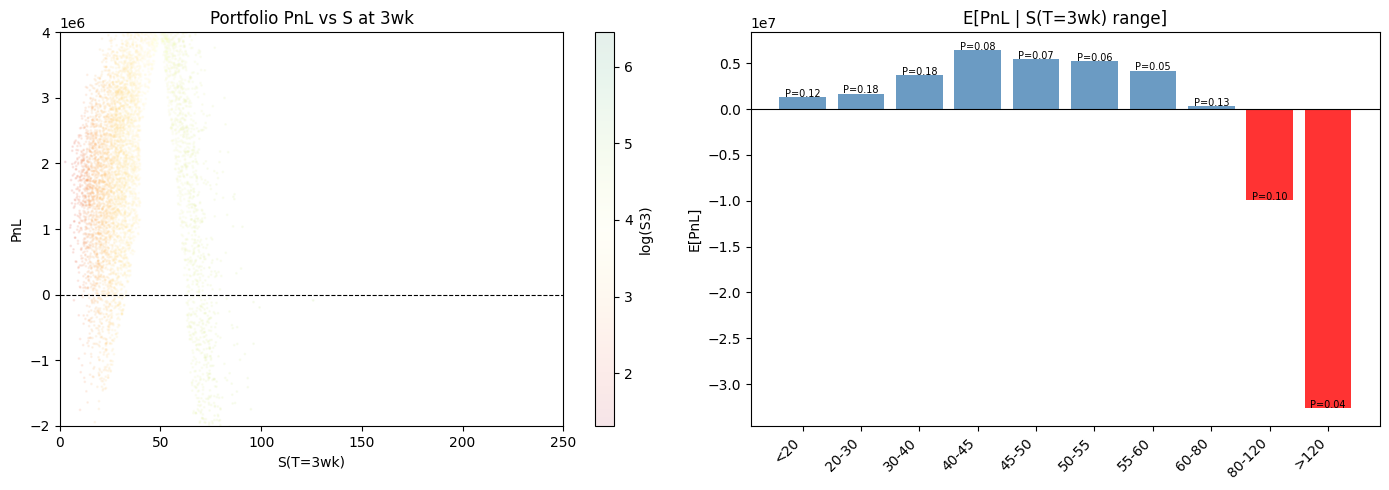

In [22]:
p_large = simulate_paths_antithetic(S0, SIGMA, 500_000, STEPS_3W, seed=42)
s2l, s3l, sml = p_large[:,STEPS_2W], p_large[:,STEPS_3W], p_large.min(axis=1)

# Per-leg PnL vectors
legs = {}
for nm,pos in positions_full.items():
    d,v,p = pos['dir'],pos['vol'],pos['price']
    legs[nm] = d*(PAYOFF_FNS[nm](s2l,s3l,sml)-p)*v*CONTRACT_SIZE

# Correlation matrix
leg_df = pd.DataFrame(legs)
corr   = leg_df.corr()
print('Pairwise PnL correlations between legs:')
print(corr.round(3).to_string())

# Tail: what happens in extreme down moves?
print('\n=== Tail Scenarios ===')
for scenario, mask, label in [
    ('S3 < 20',    s3l < 20,   'extreme crash'),
    ('S3 < 30',    s3l < 30,   'deep crash'),
    ('S3 < 40',    s3l < 40,   'significant down'),
    ('S3 40-60',   (s3l>=40)&(s3l<60), 'near ATM'),
    ('S3 > 80',    s3l > 80,   'large rally'),
    ('S3 > 120',   s3l > 120,  'extreme rally'),
    ('KO triggered', sml<=35,  'barrier breached'),
]:
    if mask.sum() < 100: continue
    total_pnl_l = leg_df.sum(axis=1)
    print(f'{scenario} (P={mask.mean():.3f}): E[PnL|scenario] = {total_pnl_l[mask].mean():>12,.0f}')

# Visualize: PnL heatmap by (S2, S3)
total_pnl_l = leg_df.sum(axis=1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(s3l[::50], total_pnl_l[::50], c=np.log(s3l[::50]+1),
                     alpha=0.1, s=1, cmap='RdYlGn')
axes[0].axhline(0, color='black', lw=0.8, linestyle='--')
axes[0].set_xlim(0, 250); axes[0].set_ylim(-2e6, 4e6)
axes[0].set_title('Portfolio PnL vs S at 3wk')
axes[0].set_xlabel('S(T=3wk)'); axes[0].set_ylabel('PnL')
plt.colorbar(sc, ax=axes[0], label='log(S3)')

# PnL by S3 bucket
s3_bins = [0,20,30,40,45,50,55,60,80,120,300]
labels  = ['<20','20-30','30-40','40-45','45-50','50-55','55-60','60-80','80-120','>120']
evs = []
for lo,hi,lab in zip(s3_bins[:-1],s3_bins[1:],labels):
    m = (s3l>=lo)&(s3l<hi)
    evs.append((lab, total_pnl_l[m].mean() if m.sum()>0 else 0, m.mean()))

x = np.arange(len(evs))
bars = axes[1].bar(x, [e[1] for e in evs],
                   color=['red' if e[1]<0 else 'steelblue' for e in evs], alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels([e[0] for e in evs], rotation=45, ha='right')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('E[PnL | S(T=3wk) range]'); axes[1].set_ylabel('E[PnL]')
for i,(lab,ev,p) in enumerate(evs):
    axes[1].text(i, ev+5000, f'P={p:.2f}', ha='center', fontsize=7)
plt.tight_layout(); plt.show()

## 9 — Final Trading Sheet

In [23]:
print('=' * 78)
print('FINAL TRADES — Round 4 Manual Trading')
print('=' * 78)
print()

final_trades = [
    ('AC_50_CO',  'SELL', 50,   22.200, mc_fv['AC_50_CO'],  'CORE: Chooser arb (overpriced by ~0.33)'),
    ('AC_50_C',   'BUY',  50,   12.050, mc_fv['AC_50_C'],   'Arb leg: long 3wk call K=50'),
    ('AC_50_P_2', 'BUY',  50,    9.750, mc_fv['AC_50_P_2'], 'Arb leg: long 2wk put K=50'),
    ('AC_40_BP',  'SELL', 50,    5.000, mc_fv['AC_40_BP'],  'Binary put overpriced (~0.23 edge)'),
    ('AC_50_C_2', 'BUY',  50,    9.750, mc_fv['AC_50_C_2'], '2wk call underpriced (~0.10 edge)'),
    ('AC_45_KO',  'BUY',  500,   0.175, mc_fv['AC_45_KO'],  'KO put underpriced (~0.031 edge, 500 vol)'),
    ('AC_60_C',   'SELL', 50,    8.800, mc_fv['AC_60_C'],   '3wk 60-strike call overpriced (~0.04)'),
    ('AETHER',    'SKIP', 0,    50.000, 50.000,              'Zero/negative edge both sides. Skip.'),
]

print(f'{"Product":<14} {"Action":>5} {"Vol":>5} {"Price":>7} {"Fair":>8} {"Edge/u":>8} {"E[PnL]":>12}  Notes')
print('─' * 95)
grand_ev = 0
for prod, action, vol, price, fv, note in final_trades:
    d    = -1 if action=='SELL' else (+1 if action=='BUY' else 0)
    edge = (fv-price)*d
    ev   = edge*vol*CONTRACT_SIZE
    grand_ev += ev
    ev_str = f'{ev:>12,.0f}' if ev != 0 else f'{"—":>12}'
    print(f'{prod:<14} {action:>5} {vol:>5} {price:>7.3f} {fv:>8.4f} {edge:>8.4f} {ev_str}  {note}')
print('─' * 95)
print(f'{"TOTAL EXPECTED PnL":>56} {grand_ev:>12,.0f}')

print()
p1M  = simulate_paths_antithetic(S0, SIGMA, 1_000_000, STEPS_3W, seed=0)
pnl1M = portfolio_pnl(p1M, positions_full)
se100 = pnl1M.std()/np.sqrt(100)
print(f'Large-sample validation (1M antithetic sims):')
print(f'  E[PnL]              = {pnl1M.mean():>12,.0f}')
print(f'  Std[PnL]            = {pnl1M.std():>12,.0f}')
print(f'  Sharpe ratio        = {pnl1M.mean()/pnl1M.std():>12.5f}')
print(f'  P(100-sim avg > 0)  = {norm.cdf(pnl1M.mean()/se100):>12.4f}  (analytical)')

print()
print('=' * 78)
print('KEY FINDINGS')
print('=' * 78)
print('''
1. CHOOSER ARB [near-riskless]
   Sell chooser + buy 3wk call + buy 2wk put.
   Net payoff = (S3-S2)·1(S2<50), which has E=0 exactly (martingale).
   Premium locked: +0.40/unit. Variance only from S3-S2 increment.

2. BINARY PUT SELL [clear mispricing]
   Fair = 4.77, bid = 5.00. Edge +0.23/unit. 95% CI excludes bid price.
   Tail risk: max loss 5.00/unit if S3 crashes. Partially offset by KO gain.

3. 2WK CALL BUY [underpriced]
   Fair = 9.85, ask = 9.75. Edge +0.10/unit.

4. KO PUT BUY [confirmed mispriced]
   Fair = 0.206, ask = 0.175. Edge +0.031/unit × 500 contracts = +47k EV.
   20 independent runs all give fair value above market ask. Robust signal.

5. UNDERLYING: SKIP
   Both bid and ask have negative expected edge (spread = 0.025, fair = 50.0).
   Net portfolio delta ≈ 1.6 units (negligible). Hedge not worth the spread cost.

6. ALL OTHER VANILLAS: FAIR or negative edge. Do not trade.

RISK: P(100-sim avg > 0) ≈ 0.67. With only 100 scoring sims, std ≈ 350k.
Cannot reduce scoring variance without adding correlated positions.
''')

FINAL TRADES — Round 4 Manual Trading

Product        Action   Vol   Price     Fair   Edge/u       E[PnL]  Notes
───────────────────────────────────────────────────────────────────────────────────────────────
AC_50_CO        SELL    50  22.200  21.8733   0.3267       49,011  CORE: Chooser arb (overpriced by ~0.33)
AC_50_C          BUY    50  12.050  11.9934  -0.0566       -8,487  Arb leg: long 3wk call K=50
AC_50_P_2        BUY    50   9.750   9.8688   0.1188       17,817  Arb leg: long 2wk put K=50
AC_40_BP        SELL    50   5.000   4.7689   0.2311       34,671  Binary put overpriced (~0.23 edge)
AC_50_C_2        BUY    50   9.750   9.8485   0.0985       14,779  2wk call underpriced (~0.10 edge)
AC_45_KO         BUY   500   0.175   0.2056   0.0306       45,835  KO put underpriced (~0.031 edge, 500 vol)
AC_60_C         SELL    50   8.800   8.7591   0.0409        6,128  3wk 60-strike call overpriced (~0.04)
AETHER          SKIP     0  50.000  50.0000   0.0000            —  Zero/negati

In [34]:
import itertools
import time
import numpy as np

# We set up the products, their max volumes, and market prices
trade_candidates = [
    ('AC_50_CO',  50,   22.200),
    ('AC_50_C',   50,   12.050),
    ('AC_50_P_2', 50,    9.750),
    ('AC_40_BP',  50,    5.000),
    ('AC_50_C_2', 50,    9.750),
    ('AC_45_KO',  500,   0.175),
    ('AC_60_C',   50,    8.800),
    ('AETHER',    50,   50.000), 
]

# Ensure paths are generated for evaluation. Fallback on recreating them if p_large doesn't exist
if 'p_large' not in locals():
    print("Generating simulated paths...")
    p_large = simulate_paths_antithetic(S0, SIGMA, 200_000, STEPS_3W, seed=42)

s2l, s3l, sml = p_large[:, STEPS_2W], p_large[:, STEPS_3W], p_large.min(axis=1)

print("Pre-computing PnL vectors for each leg (optimization step)...")
leg_pnls = []
for prod, vol, price in trade_candidates:
    # Evaluate PnL for BUYING 1 full position of size `vol`
    payoff = PAYOFF_FNS[prod](s2l, s3l, sml)
    leg_pnl = (payoff - price) * vol * CONTRACT_SIZE
    leg_pnls.append(leg_pnl)

# Matrix shape: (num_products, num_paths)
leg_pnls = np.array(leg_pnls)

# Generate Combinations: -1 (SELL), 0 (SKIP), 1 (BUY)
actions = [-1, 0, 1]
combinations = list(itertools.product(actions, repeat=len(trade_candidates)))
total_sims = len(combinations)

best_sharpe = -np.inf
best_comb = None
best_metrics = {}
best_pnl = None
best_pnl_metrics = {}

start_time = time.time()
update_interval = max(1, total_sims // 100) # Print updates ~100 times during loop

print(f"Starting search across {total_sims} possible combinations...\n")

for i, comb in enumerate(combinations):
    # Vectorized calculation: Multiply leg PnLs by our current direction choices and sum across paths
    comb_weights = np.array(comb).reshape(-1, 1)
    port_pnl = np.sum(leg_pnls * comb_weights, axis=0)

    
    ev = port_pnl.mean()
    std = port_pnl.std()
    
    if port_pnl > best_pnl:
        best_pnl = port_pnl
        best_pnl_metrics = {'EV': ev, 'Std': std, 'Sharpe': sharpe}
        
    # We want a portfolio with positive expected value!
    if ev > 0 and std > 0:
        sharpe = ev / std
        if sharpe > best_sharpe:
            best_sharpe = sharpe
            best_comb = comb
            best_metrics = {'EV': ev, 'Std': std, 'Sharpe': sharpe}
            
    # Calculate simulations processed and remaining time dynamically
    if (i + 1) % update_interval == 0 or (i + 1) == total_sims:
        elapsed = time.time() - start_time
        rate = (i + 1) / elapsed if elapsed > 0 else 0
        rem_time = (total_sims - (i + 1)) / rate if rate > 0 else 0
        
        # Updating output in-place
        print(f"\rProgressBar: {i + 1}/{total_sims} [{(i + 1)/total_sims*100:>5.1f}%] | "
              f"Elapsed: {elapsed:>4.1f}s | Remaining: {rem_time:>4.1f}s", end="")

print("\n\n" + "="*65)
print("BEST COMBINATION FOUND (Maximized for Sharpe Ratio)")
print("="*65)
for (prod, vol, price), d in zip(trade_candidates, best_comb):
    action_str = 'BUY' if d == 1 else ('SELL' if d == -1 else 'SKIP')
    print(f"{prod:<12} : {action_str:>5} (Vol: {vol})")

print("-" * 65)
if best_comb:
    print(f"Expected PnL : {best_metrics['EV']:>12,.0f}")
    print(f"Std Dev      : {best_metrics['Std']:>12,.0f}")
    print(f"Sharpe Ratio : {best_metrics['Sharpe']:>12.5f}")
else:
    print("No combination found with a positive Expected Value.")
print("=" * 65)


Pre-computing PnL vectors for each leg (optimization step)...
Starting search across 6561 possible combinations...



TypeError: '>' not supported between instances of 'float' and 'NoneType'

In [38]:
import itertools
import time
import numpy as np

# Total Market Data from your notebook
market_data = {
    'AC_50_C':   (12.000, 12.050, 50),
    'AC_50_P':   (12.000, 12.050, 50),
    'AC_35_P':   (4.330,  4.350,  50),
    'AC_40_P':   (6.500,  6.550,  50),
    'AC_45_P':   (9.050,  9.100,  50),
    'AC_60_C':   (8.800,  8.850,  50),
    'AC_50_C_2': (9.700,  9.750,  50),
    'AC_50_P_2': (9.700,  9.750,  50),
    'AC_50_CO':  (22.200, 22.300, 50),
    'AC_40_BP':  (5.000,  5.100,  50),
    'AC_45_KO':  (0.150,  0.175,  500),
    'AETHER':    (49.975, 50.025, 200),
}

prod_names = list(market_data.keys())
N_PRODS = len(prod_names)

# Ensure paths are ready
if 'p_large' not in locals():
    print("Generating simulated paths...")
    p_large = simulate_paths_antithetic(S0, SIGMA, 200_000, STEPS_3W, seed=42)

s2l, s3l, sml = p_large[:, STEPS_2W], p_large[:, STEPS_3W], p_large.min(axis=1)

print("Mapping Payoff Functions...")
# Copy fns from notebook and dynamically fill missing ones
local_fns = PAYOFF_FNS.copy()

for p in prod_names:
    if p in local_fns: continue
    # Dynamic logic for standard vanillas: AC_XX_C or AC_XX_P
    try:
        parts = p.split('_')
        strike = float(parts[1])
        if parts[2] == 'C':
            local_fns[p] = lambda s2, s3, sm, k=strike: np.maximum(s3 - k, 0)
        elif parts[2] == 'P':
            local_fns[p] = lambda s2, s3, sm, k=strike: np.maximum(k - s3, 0)
    except:
        print(f"Warning: Could not define automatic logic for {p}")

payoffs_matrix = []
for p in prod_names:
    payoffs_matrix.append(local_fns[p](s2l, s3l, sml))

payoffs_matrix = np.array(payoffs_matrix)
mean_payoffs = payoffs_matrix.mean(axis=1)
cov_payoffs = np.cov(payoffs_matrix, bias=True)

bids = np.array([market_data[p][0] for p in prod_names])
asks = np.array([market_data[p][1] for p in prod_names])
vols = np.array([market_data[p][2] for p in prod_names])

sell_cash = bids * vols * CONTRACT_SIZE 
buy_cash  = asks * vols * CONTRACT_SIZE 

# Brute force search
actions = [-1, 0, 1]
combinations = list(itertools.product(actions, repeat=N_PRODS))
total_sims = len(combinations)

best_sharpe = -np.inf
best_sharpe_comb = None
best_pnl = -np.inf
best_pnl_comb = None

start_time = time.time()
update_interval = total_sims // 50

print(f"Evaluating {total_sims:,} trade combinations...\n")

for i, comb in enumerate(combinations):
    comb_arr = np.array(comb)
    w = comb_arr * vols * CONTRACT_SIZE
    
    # Total PnL = (Expiry Value) + (Initial Cash Flow)
    ev = w.dot(mean_payoffs) + (np.sum(sell_cash[comb_arr == -1]) - np.sum(buy_cash[comb_arr == 1]))
    
    if np.any(comb_arr != 0):
        # Tracking Max PnL
        if ev > best_pnl:
            var = w.dot(cov_payoffs).dot(w)
            std = np.sqrt(max(0, var))
            best_pnl = ev
            best_pnl_comb = (comb, ev, std)
            
        # Tracking Max Sharpe
        if ev > 0:
            var = w.dot(cov_payoffs).dot(w)
            std = np.sqrt(max(0, var))
            if std > 0:
                sharpe = ev / std
                if sharpe > best_sharpe:
                    best_sharpe = sharpe
                    best_sharpe_comb = (comb, ev, std, sharpe)

    if (i + 1) % update_interval == 0:
        elapsed = time.time() - start_time
        remain = (elapsed / (i + 1)) * (total_sims - (i + 1))
        print(f"\rProgress: {(i+1)/total_sims*100:4.1f}% | Elapsed: {elapsed:4.1f}s | ETC: {remain:4.1f}s", end="")

def print_results(title, data):
    print(f"\n\n{'='*70}\n{title}\n{'='*70}")
    comb, ev, std = data[0], data[1], data[2]
    print(f"{'Product':<12} : {'Action':<6} {'Units':<6} {'@ Price':<8}")
    for name, d in zip(prod_names, comb):
        if d == 0: continue
        act = "BUY" if d == 1 else "SELL"
        p = market_data[name][1] if d == 1 else market_data[name][0]
        print(f"{name:<12} : {act:<6} {market_data[name][2]:<6} @ {p:>7.3f}")
    print("-" * 70)
    print(f"Total Expected PnL : {ev:>12,.0f}")
    print(f"Standard Deviation : {std:>12,.0f}")
    if len(data) > 3: print(f"Sharpe Ratio       : {data[3]:>12.5f}")

if best_pnl_comb: print_results("BEST COMBINATION BY TOTAL EXPECTED PnL", best_pnl_comb)
if best_sharpe_comb: print_results("BEST COMBINATION BY SHARPE RATIO", best_sharpe_comb)


Mapping Payoff Functions...
Evaluating 531,441 trade combinations...

Progress: 100.0% | Elapsed:  5.1s | ETC:  0.0s

BEST COMBINATION BY TOTAL EXPECTED PnL
Product      : Action Units  @ Price 
AC_50_C      : SELL   50     @  12.000
AC_35_P      : SELL   50     @   4.330
AC_60_C      : SELL   50     @   8.800
AC_50_C_2    : BUY    50     @   9.750
AC_50_P_2    : BUY    50     @   9.750
AC_50_CO     : SELL   50     @  22.200
AC_40_BP     : SELL   50     @   5.000
AC_45_KO     : BUY    500    @   0.175
AETHER       : SELL   200    @  49.975
----------------------------------------------------------------------
Total Expected PnL :      170,666
Standard Deviation :   27,866,142


BEST COMBINATION BY SHARPE RATIO
Product      : Action Units  @ Price 
AC_35_P      : SELL   50     @   4.330
AC_45_P      : BUY    50     @   9.100
AC_40_BP     : SELL   50     @   5.000
----------------------------------------------------------------------
Total Expected PnL :       32,040
Standard Deviation :